# [Laminar] Lid-driven Cavity

## Preamble

In [1]:
# Standard Library
import sys
import os
from pathlib import Path
import foamnordic as fno
import numpy as np
import matplotlib.pyplot as plt
import onsaemiro as osm

### Directory & Path

In [2]:
# FoamNordic Project Directory
PROJECT_DIR = Path("/scratch/<allocation-account>/<user>")
CASE_TYPE = "laminar"
CASE_NAME = "lidDrivenCavity"
BASE_DIR = PROJECT_DIR / "Codes" / "FoamNordic"
MAIN_DIR = BASE_DIR / "tutorials" / "foamnordic_tutorials" / "incompressible"
OF_SCRIPT_DIR = BASE_DIR / "tutorials" / "openfoam_tutorials" / "incompressible" / CASE_TYPE / CASE_NAME

# Output Directory
OUTPUT_DIR = MAIN_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Configuration

In [3]:
# DataGraph Configuration
FIG_X, FIG_Y = 3.5, 2.55
FIGURE_SIZE = (FIG_X, FIG_Y)
PALETTE = osm.get_palette("OKABE_ITO")
osm.set_style(figure_size=FIGURE_SIZE)

In [ ]:
# HPC configuration
ACCOUNT = "<allocation-account>" # e.g. project_xxxxxxx
PARTITION = "small"
TIME = "00:15:00"
N_NODES = 1
N_TASKS = 1
CPUS_PER_TASK = 1
MEM_PER_CPU = "4G"

# FoamNordic Slurm configuration
of_scheduler = fno.Slurm.openfoam(
    nodes=N_NODES,
    ntasks=N_TASKS,
    cpus_per_task=CPUS_PER_TASK,
    mem_per_cpu=MEM_PER_CPU,
)

model_scheduler = fno.Slurm.model(
    cpus_per_task=1,
    mem_per_cpu=MEM_PER_CPU
)

scheduler = fno.Slurm(
    account=ACCOUNT,
    partition=PARTITION,
    time=TIME,
    openfoam=of_scheduler,
    model=model_scheduler
)

In [5]:
# FoamNordic configuration
SEED = 42
key = fno.Random.key(seed=SEED, scope="global")

## Example - Field Coupling

### Case Definition

In [6]:
# Define a custom operator to perturb the velocity field
def perturb_velocity(velocity, *, key):
    key, subkey = fno.Random.split(key, 2)
    scale = fno.Random.uniform(subkey, low=0.995, high=1.005)
    updated_velocity = velocity * scale
    return {"updated_velocity": updated_velocity}

velocity_transform = fno.Transform(
    name="perturbVelocity",
    operator=fno.Operator.function(perturb_velocity),
    inputs={"velocity": fno.Field("U")},
    outputs={"updated_velocity": fno.Field("U")},
    at="time_step_start",
    key=key,
)

In [7]:
# Initialize the OpenFOAM case
case = fno.OpenFOAM.Case(
    name="lidDrivenCavity",
    case_dir=OF_SCRIPT_DIR,
    run_dir=OUTPUT_DIR,
    of_cmd="module load openfoam/2512",
    shell="bash",
    application="pimpleFoam",
    ranks=N_TASKS,
)

### Observer Defintion

In [8]:
# Define field observations to monitor during the simulation
observations = fno.Observe(
    summaries={
        "U": ("min", "max", "mean", "l2"),
        "p": ("min", "max", "mean"),
    },
    interval=10,
)

### Submit Job

In [9]:
# Connect the OpenFOAM case and SLURM scheduler (launch a longship instance)
longship = fno.Longship(case=case, scheduler=scheduler,
                        transforms=(velocity_transform,),
                        observations=(observations,),
                        verbose=True)

# Set sail for the OpenFOAM case (submit the job to the HPC cluster)
run = longship.launch(start_timeout=900)
records = list(run.observe(progress=True))

Resource,OpenFOAM,Model,Allocation
Processes,1 tasks,1 host(s),1 node(s)
CPU,1 cores,1 cores,2 cores
Memory,4 GiB,4 GiB,8.03125 GiB
Field programs,-,1,1
SHM,-,~32 MiB,~32 MiB


[FoamNordic] Sailing submitted with Job ID: 870054
[FoamNordic] Sailing has launched with Job ID: 870054
[FoamNordic] Sailing started at: 2026-08-26T09:29:52
[FoamNordic] Sailing in background: lidDrivenCavity


In [10]:
# Wait for the job to complete (polling the job status)
result = run.stop(force=False, timeout=3600, progress=True)

In [11]:
# Summary of the job result
result.summary(style="compact");

Job ID,Name,Status,Partition,Node,Elapsed
870054,lidDrivenCavity,succeeded,small,rc4141,00:00:53


### Postprocessing

In [12]:
# Postprocessing
post = result.postprocess

velocity = post.field("U", time_idx=-1)
pressure = post.field("p", time_idx=-1)

print("U shape:", velocity.shape)
print("p shape:", pressure.shape)

statistics = post.statistics(
    ["U", "p"],
    time_idx=-1,
    verbose=True,
)

U shape: (4096, 3)
p shape: (4096,)


Field,Min,Max,Mean,Std,RMS
U,7.039078e-06,8.710882e-01,1.980805e-01,1.517841e-01,2.495482e-01
p,-1.209080e-01,6.000540e-01,-2.677977e-02,3.899099e-02,4.730173e-02


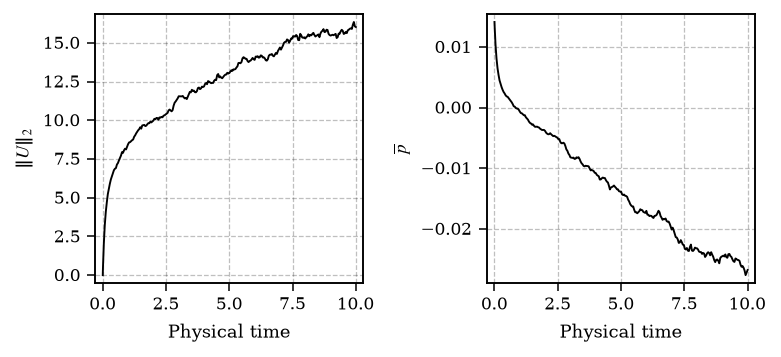

In [13]:
# Visualisation of the field statistics
physical_time = np.asarray([record.time for record in records])

def extract_stat(records, field, stat):
    return np.asarray([getattr(rec.summary[field], stat) for rec in records])

u_l2 = extract_stat(records, "U", "l2")
p_mean = extract_stat(records, "p", "mean")

fig, axes = plt.subplots(1, 2, figsize=(FIG_X*1.5, FIG_Y))

axes[0].plot(physical_time, u_l2, c=PALETTE["black"])
axes[0].set_xlabel("Physical time")
axes[0].set_ylabel(r"$\Vert U \Vert_2$")

axes[1].plot(physical_time, p_mean, c=PALETTE["black"])
axes[1].set_xlabel("Physical time")
axes[1].set_ylabel(r"$\overline{p}$")

for axis in axes:
    axis.grid(alpha=0.25)
    axis.set_box_aspect(1)

fig.tight_layout()
plt.show()

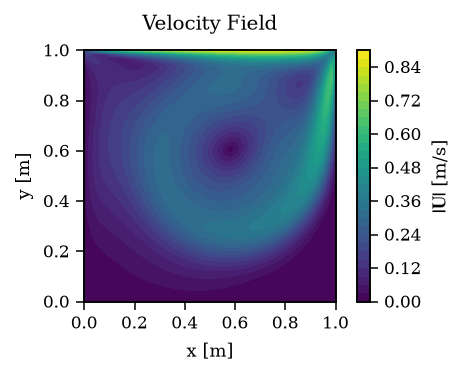

In [14]:
# Postprocessing with class
postprocessor = fno.Postprocess.Case(result)

# Load fields from the postprocessor (shape: (4096, 3) for U, (4096,) for p)
U = postprocessor.field("U", time_idx=-1)
p = postprocessor.field("p", time_idx=-1)

# Grid parameters for 2D lid-driven cavity (64x64 uniform grid, L = 1.0m)
n_cells = int(np.sqrt(len(U)))
L = 1.0
x = np.linspace(0, L, n_cells)
y = np.linspace(0, L, n_cells)
X, Y = np.meshgrid(x, y)

# Reshape field components to 2D structured mesh without transpose
u_x = U[:, 0].reshape(n_cells, n_cells)
u_y = U[:, 1].reshape(n_cells, n_cells)
u_mag = np.linalg.norm(U[:, :2], axis=1).reshape(n_cells, n_cells)
pressure_2d = p.reshape(n_cells, n_cells)

# Visualisation of velocity magnitude and streamlines
fig, ax = plt.subplots(figsize=FIGURE_SIZE)

contour = ax.contourf(X, Y, u_mag, levels=30, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label(r"$|\mathbf{U}|$ [m/s]")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Velocity Field")
ax.set_aspect("equal")

fig.tight_layout()
plt.show()